In [3]:
# ============================================================
# PART 1 - INSTALL AND IMPORT LIBRARIES
# ============================================================

!pip install -q lightgbm

import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
    classification_report
)

from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")

print("=" * 70)
print("E-COMMERCE PURCHASE PREDICTION")
print("=" * 70)
print("Libraries imported successfully!")

E-COMMERCE PURCHASE PREDICTION
Libraries imported successfully!


In [4]:
import os
import pandas as pd

# Portable dataset locator
possible_paths = [
    '../2019-Oct.csv',
    '2019-Oct.csv',
    'd:/FYP/implementation/2019-Oct.csv',
    '/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Oct.csv'
]
data_path = None
for p in possible_paths:
    if os.path.exists(p):
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError('Could not find 2019-Oct.csv dataset.')

print(f'Loading dataset from: {data_path}')
nov_df = pd.read_csv(
    data_path,
    nrows=100000
)

print('Dataset loaded successfully!')
print('Shape:', nov_df.shape)
display(nov_df.head())


(100000, 9)
Dataset loaded successfully!
Shape: (100000, 9)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [5]:
# ============================================================
# STEP 2 — DATASET INSPECTION
# ============================================================

print("=" * 60)
print("DATASET INSPECTION")
print("=" * 60)

# 1. Column names
print("\n1. Columns:")
print(nov_df.columns.tolist())

# 2. Dataset information
print("\n2. Dataset Info:")
nov_df.info()

# 3. Missing values
print("\n3. Missing Values:")
print(nov_df.isnull().sum())

# 4. Duplicate rows
print("\n4. Duplicate Rows:")
print(nov_df.duplicated().sum())

# 5. Event type distribution
print("\n5. Event Type Distribution:")
print(nov_df["event_type"].value_counts())

# 6. Number of unique sessions
print("\n6. Unique Sessions:")
print(nov_df["user_session"].nunique())

# 7. Number of unique users
print("\n7. Unique Users:")
print(nov_df["user_id"].nunique())



DATASET INSPECTION

1. Columns:
['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']

2. Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     100000 non-null  object 
 1   event_type     100000 non-null  object 
 2   product_id     100000 non-null  int64  
 3   category_id    100000 non-null  int64  
 4   category_code  67413 non-null   object 
 5   brand          85607 non-null   object 
 6   price          100000 non-null  float64
 7   user_id        100000 non-null  int64  
 8   user_session   100000 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 6.9+ MB

3. Missing Values:
event_time           0
event_type           0
product_id           0
category_id          0
category_code    32587
brand            14393
price 

In [6]:
# ============================================================
# STEP 3 — DATA PREPROCESSING
# ============================================================

print("=" * 60)
print("DATA PREPROCESSING")
print("=" * 60)

# ------------------------------------------------------------
# 1. Remove duplicate records
# ------------------------------------------------------------

before_duplicates = len(nov_df)

nov_df = nov_df.drop_duplicates()

after_duplicates = len(nov_df)

print("\n1. Duplicate Removal")
print("Rows before :", before_duplicates)
print("Rows after  :", after_duplicates)
print("Duplicates removed :", before_duplicates - after_duplicates)


# ------------------------------------------------------------
# 2. Handle missing brand values
# ------------------------------------------------------------

missing_brand_before = nov_df["brand"].isnull().sum()

nov_df["brand"] = nov_df["brand"].fillna("unknown")

missing_brand_after = nov_df["brand"].isnull().sum()

print("\n2. Missing Brand Handling")
print("Missing brand before :", missing_brand_before)
print("Missing brand after  :", missing_brand_after)


# ------------------------------------------------------------
# 3. Remove category_code
# ------------------------------------------------------------

if "category_code" in nov_df.columns:
    nov_df = nov_df.drop(columns=["category_code"])

print("\n3. category_code")
print("category_code column removed ✓")


# ------------------------------------------------------------
# 4. Convert event_time to datetime
# ------------------------------------------------------------

nov_df["event_time"] = pd.to_datetime(
    nov_df["event_time"]
)

print("\n4. Timestamp Conversion")
print("event_time datatype :", nov_df["event_time"].dtype)


# ------------------------------------------------------------
# 5. Sort events chronologically within each session
# ------------------------------------------------------------

nov_df = nov_df.sort_values(
    ["user_session", "event_time"]
).reset_index(drop=True)

print("\n5. Session Sorting")
print("Events sorted by user_session and event_time ✓")


# ------------------------------------------------------------
# FINAL CHECK
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PREPROCESSING SUMMARY")
print("=" * 60)

print("Final rows    :", len(nov_df))
print("Final columns :", len(nov_df.columns))
print("Missing values:")
print(nov_df.isnull().sum())

print("\nFinal columns:")
print(nov_df.columns.tolist())

DATA PREPROCESSING

1. Duplicate Removal
Rows before : 100000
Rows after  : 99983
Duplicates removed : 17

2. Missing Brand Handling
Missing brand before : 14388
Missing brand after  : 0

3. category_code
category_code column removed ✓

4. Timestamp Conversion
event_time datatype : datetime64[ns, UTC]

5. Session Sorting
Events sorted by user_session and event_time ✓

PREPROCESSING SUMMARY
Final rows    : 99983
Final columns : 8
Missing values:
event_time      0
event_type      0
product_id      0
category_id     0
brand           0
price           0
user_id         0
user_session    0
dtype: int64

Final columns:
['event_time', 'event_type', 'product_id', 'category_id', 'brand', 'price', 'user_id', 'user_session']


In [7]:
# ============================================================
# STEP 4 — CREATE SESSION-LEVEL PURCHASE LABEL
# ============================================================

print("=" * 60)
print("PURCHASE LABEL CREATION")
print("=" * 60)

# Check purchase events
purchase_events = (
    nov_df["event_type"] == "purchase"
).sum()

print("\nPurchase events found:", purchase_events)

# Create purchase label for each session
session_labels = (
    nov_df.groupby("user_session")["event_type"]
    .apply(lambda events: int("purchase" in events.values))
    .reset_index(name="purchase")
)

print("\nPurchase label created successfully ✓")

# ------------------------------------------------------------
# Display label distribution
# ------------------------------------------------------------

print("\nSession-level purchase distribution:")
print(session_labels["purchase"].value_counts())

print("\nPurchase percentage:")

purchase_percentage = (
    session_labels["purchase"].mean() * 100
)

print(f"{purchase_percentage:.2f}% of sessions resulted in purchase")

# ------------------------------------------------------------
# Display sample
# ------------------------------------------------------------

print("\nSample session labels:")
display(session_labels.head(10))

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PURCHASE LABEL SUMMARY")
print("=" * 60)

print("Total sessions :", len(session_labels))
print(
    "Purchase sessions :",
    (session_labels["purchase"] == 1).sum()
)
print(
    "Non-purchase sessions :",
    (session_labels["purchase"] == 0).sum()
)

print("\nSTEP 4 COMPLETED ✓")
print("=" * 60)

PURCHASE LABEL CREATION

Purchase events found: 1655

Purchase label created successfully ✓

Session-level purchase distribution:
purchase
0    22951
1     1431
Name: count, dtype: int64

Purchase percentage:
5.87% of sessions resulted in purchase

Sample session labels:


,user_session,purchase
0,00056e5c-f5b0-464b-84d0-d5d02197c4da,0
1,0006852b-f9a2-4d84-b439-acc1f9e6771e,0
2,000c2fd2-561a-4abd-bd21-5e71449b1b78,0
3,000c8aaa-d614-433a-9621-a53629f39fd9,0
4,001259d1-d126-4601-a53e-b511cf3a3152,0
5,001928f2-e689-446a-a5d8-27d8e1018a1c,0
6,001f8c1d-dc62-4f75-9339-fda1772626f4,0
7,0020f3c3-71cd-4d8f-8a1e-e559f7979a4d,0
8,0029707a-c11a-4c1d-aaec-f27a882eb458,0
9,00322ee2-5eec-4647-9499-eae70633ec5b,0



PURCHASE LABEL SUMMARY
Total sessions : 24382
Purchase sessions : 1431
Non-purchase sessions : 22951

STEP 4 COMPLETED ✓


In [8]:
# ============================================================
# STEP 5 — REMOVE PURCHASE EVENTS
# ============================================================

print("=" * 60)
print("STEP 5 — REMOVE PURCHASE EVENTS")
print("=" * 60)

# Number of rows before removal
rows_before = len(nov_df)

# Number of purchase events
purchase_events_before = (
    nov_df["event_type"] == "purchase"
).sum()

print("\nBefore removal:")
print("Total events      :", rows_before)
print("Purchase events   :", purchase_events_before)

# Remove purchase events
nov_df = nov_df[
    nov_df["event_type"] != "purchase"
].copy()

# Number of rows after removal
rows_after = len(nov_df)

purchase_events_after = (
    nov_df["event_type"] == "purchase"
).sum()

print("\nAfter removal:")
print("Total events      :", rows_after)
print("Purchase events   :", purchase_events_after)

print("\nEvents removed:", rows_before - rows_after)

print("\nEvent distribution after removing purchases:")
print(nov_df["event_type"].value_counts())


STEP 5 — REMOVE PURCHASE EVENTS

Before removal:
Total events      : 99983
Purchase events   : 1655

After removal:
Total events      : 98328
Purchase events   : 0

Events removed: 1655

Event distribution after removing purchases:
event_type
view    97121
cart     1207
Name: count, dtype: int64


In [9]:
# ============================================================
# STEP 6 — REMOVE SHORT SESSIONS
# ============================================================

print("=" * 60)
print("STEP 6 — REMOVE SESSIONS WITH FEWER THAN 3 ACTIONS")
print("=" * 60)

# Count actions in each session
session_action_counts = (
    nov_df.groupby("user_session")
    .size()
    .rename("action_count")
)

print("\nSession action statistics BEFORE filtering:")
print(session_action_counts.describe())

# Count sessions before filtering
sessions_before = nov_df["user_session"].nunique()

# Keep only sessions with at least 3 actions
valid_sessions = session_action_counts[
    session_action_counts >= 3
].index

nov_df = nov_df[
    nov_df["user_session"].isin(valid_sessions)
].copy()

# Count sessions after filtering
sessions_after = nov_df["user_session"].nunique()

print("\n" + "=" * 60)
print("SHORT SESSION REMOVAL RESULTS")
print("=" * 60)

print("Sessions before filtering :", sessions_before)
print("Sessions after filtering  :", sessions_after)
print("Sessions removed          :", sessions_before - sessions_after)

print("\nRemaining events :", len(nov_df))

print("\nRemaining event distribution:")
print(nov_df["event_type"].value_counts())

# Check minimum session length
minimum_actions = (
    nov_df.groupby("user_session")
    .size()
    .min()
)

print("\nMinimum actions in remaining sessions:", minimum_actions)


STEP 6 — REMOVE SESSIONS WITH FEWER THAN 3 ACTIONS

Session action statistics BEFORE filtering:
count    24376.000000
mean         4.033804
std          5.496166
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        113.000000
Name: action_count, dtype: float64

SHORT SESSION REMOVAL RESULTS
Sessions before filtering : 24376
Sessions after filtering  : 10681
Sessions removed          : 13695

Remaining events : 80183

Remaining event distribution:
event_type
view    79097
cart     1086
Name: count, dtype: int64

Minimum actions in remaining sessions: 3


In [10]:
# ============================================================
# STEP 7 — SESSION-LEVEL FEATURE ENGINEERING
# ============================================================

print("=" * 60)
print("STEP 7 — SESSION-LEVEL FEATURE ENGINEERING")
print("=" * 60)

# ------------------------------------------------------------
# Create session-level aggregated features
# ------------------------------------------------------------

session_features = (
    nov_df.groupby("user_session")
    .agg(
        # Number of actions
        event_count=("event_type", "count"),

        # Event type counts
        view_count=("event_type", lambda x: (x == "view").sum()),
        cart_count=("event_type", lambda x: (x == "cart").sum()),

        # Product/category/brand behavior
        unique_products=("product_id", "nunique"),
        unique_categories=("category_id", "nunique"),
        unique_brands=("brand", "nunique"),

        # Price behavior
        average_price=("price", "mean"),
        max_price=("price", "max"),
        min_price=("price", "min"),

        # Time information
        session_start=("event_time", "min"),
        session_end=("event_time", "max"),

        # User information
        user_id=("user_id", "first")
    )
    .reset_index()
)

# ------------------------------------------------------------
# Calculate session duration
# ------------------------------------------------------------

session_features["session_duration"] = (
    session_features["session_end"] -
    session_features["session_start"]
).dt.total_seconds()

# ------------------------------------------------------------
# Calculate session start time features
# ------------------------------------------------------------

session_features["hour"] = (
    session_features["session_start"].dt.hour
)

session_features["day_of_week"] = (
    session_features["session_start"].dt.dayofweek
)

session_features["is_weekend"] = (
    session_features["day_of_week"] >= 5
).astype(int)

# ------------------------------------------------------------
# Merge purchase label
# ------------------------------------------------------------

session_features = session_features.merge(
    session_labels,
    on="user_session",
    how="left"
)

# ------------------------------------------------------------
# Handle any missing values
# ------------------------------------------------------------

session_features["purchase"] = (
    session_features["purchase"]
    .fillna(0)
    .astype(int)
)

# Fill numerical missing values
numeric_columns = session_features.select_dtypes(
    include=np.number
).columns

session_features[numeric_columns] = (
    session_features[numeric_columns]
    .fillna(0)
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("AGGREGATED SESSION FEATURES CREATED")
print("=" * 60)

print("Number of sessions :", len(session_features))
print("Number of features :", len(session_features.columns))

print("\nFeature names:")
for i, column in enumerate(session_features.columns, 1):
    print(f"{i:2}. {column}")

print("\nSample session features:")
display(session_features.head())

print("\nPurchase distribution:")
print(session_features["purchase"].value_counts())

print("\nFeature dataset shape:")
print(session_features.shape)


STEP 7 — SESSION-LEVEL FEATURE ENGINEERING

AGGREGATED SESSION FEATURES CREATED
Number of sessions : 10681
Number of features : 18

Feature names:
 1. user_session
 2. event_count
 3. view_count
 4. cart_count
 5. unique_products
 6. unique_categories
 7. unique_brands
 8. average_price
 9. max_price
10. min_price
11. session_start
12. session_end
13. user_id
14. session_duration
15. hour
16. day_of_week
17. is_weekend
18. purchase

Sample session features:


,user_session,event_count,view_count,cart_count,unique_products,unique_categories,unique_brands,average_price,max_price,min_price,session_start,session_end,user_id,session_duration,hour,day_of_week,is_weekend,purchase
0,001928f2-e689-446a-a5d8-27d8e1018a1c,10,10,0,7,1,2,183.932000,295.98,117.88,2019-10-01 04:21:03+00:00,2019-10-01 04:27:57+00:00,513982020,414.0,4,1,0,0
1,0020f3c3-71cd-4d8f-8a1e-e559f7979a4d,10,10,0,8,4,7,207.864000,461.27,12.84,2019-10-01 04:18:17+00:00,2019-10-01 04:28:12+00:00,555481025,595.0,4,1,0,0
2,0029707a-c11a-4c1d-aaec-f27a882eb458,6,6,0,3,1,2,687.305000,860.85,437.33,2019-10-01 04:02:06+00:00,2019-10-01 04:05:02+00:00,555478644,176.0,4,1,0,0
3,00399d10-e0d3-4d17-9760-30c42851777c,3,3,0,1,1,1,1012.190000,1012.19,1012.19,2019-10-01 03:04:13+00:00,2019-10-01 03:05:45+00:00,514523666,92.0,3,1,0,0
4,003e20f1-1013-407c-9931-0250934600bd,3,3,0,3,1,2,155.043333,245.31,103.73,2019-10-01 03:45:08+00:00,2019-10-01 03:45:56+00:00,520075976,48.0,3,1,0,0



Purchase distribution:
purchase
0    9730
1     951
Name: count, dtype: int64

Feature dataset shape:
(10681, 18)


In [11]:
# ============================================================
# STEP 8 — RECENT ACTION REPRESENTATION
# ============================================================

print("=" * 60)
print("STEP 8 — LAST 5 ACTIONS REPRESENTATION")
print("=" * 60)

# Number of recent actions
N = 5

# ------------------------------------------------------------
# 1. Sort events chronologically
# ------------------------------------------------------------

action_data = nov_df.sort_values(
    ["user_session", "event_time"]
).copy()

# ------------------------------------------------------------
# 2. Encode event types
# ------------------------------------------------------------

event_mapping = {
    "view": 1,
    "cart": 2
}

action_data["event_code"] = (
    action_data["event_type"]
    .map(event_mapping)
    .fillna(0)
    .astype(int)
)

# ------------------------------------------------------------
# 3. Keep the LAST 5 actions from each session
# ------------------------------------------------------------

recent_actions = (
    action_data
    .groupby("user_session")
    .tail(N)
    .copy()
)

print("\nTotal sessions :", nov_df["user_session"].nunique())
print("Recent action records :", len(recent_actions))

# ------------------------------------------------------------
# 4. Number the actions within each session
# ------------------------------------------------------------

recent_actions["action_position"] = (
    recent_actions
    .groupby("user_session")
    .cumcount()
)

# ------------------------------------------------------------
# 5. Convert actions into columns
# ------------------------------------------------------------

recent_features = recent_actions.pivot(
    index="user_session",
    columns="action_position",
    values="event_code"
)

# ------------------------------------------------------------
# 6. Rename columns
# ------------------------------------------------------------

recent_features.columns = [
    f"last_action_{i+1}"
    for i in recent_features.columns
]

recent_features = recent_features.reset_index()

# ------------------------------------------------------------
# 7. Ensure all 5 action columns exist
# ------------------------------------------------------------

for i in range(1, N + 1):

    column = f"last_action_{i}"

    if column not in recent_features.columns:
        recent_features[column] = 0

# Keep correct order
recent_features = recent_features[
    ["user_session"] +
    [f"last_action_{i}" for i in range(1, N + 1)]
]

# ------------------------------------------------------------
# 8. Fill missing actions with 0
# ------------------------------------------------------------

recent_features = recent_features.fillna(0)

# Convert action columns to integers
action_columns = [
    f"last_action_{i}"
    for i in range(1, N + 1)
]

recent_features[action_columns] = (
    recent_features[action_columns]
    .astype(int)
)

# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("RECENT ACTION REPRESENTATION CREATED")
print("=" * 60)

print("Number of sessions :", len(recent_features))
print("Number of features :", len(recent_features.columns))

print("\nFeature columns:")
print(recent_features.columns.tolist())

print("\nAction encoding:")
print("0 = Padding / no action")
print("1 = View")
print("2 = Cart")

print("\nSample recent-action features:")
display(recent_features.head(10))

print("\nAction feature statistics:")
display(
    recent_features[action_columns].describe()
)



STEP 8 — LAST 5 ACTIONS REPRESENTATION

Total sessions : 10681
Recent action records : 46193

RECENT ACTION REPRESENTATION CREATED
Number of sessions : 10681
Number of features : 6

Feature columns:
['user_session', 'last_action_1', 'last_action_2', 'last_action_3', 'last_action_4', 'last_action_5']

Action encoding:
0 = Padding / no action
1 = View
2 = Cart

Sample recent-action features:


,user_session,last_action_1,last_action_2,last_action_3,last_action_4,last_action_5
0,001928f2-e689-446a-a5d8-27d8e1018a1c,1,1,1,1,1
1,0020f3c3-71cd-4d8f-8a1e-e559f7979a4d,1,1,1,1,1
2,0029707a-c11a-4c1d-aaec-f27a882eb458,1,1,1,1,1
3,00399d10-e0d3-4d17-9760-30c42851777c,1,1,1,0,0
4,003e20f1-1013-407c-9931-0250934600bd,1,1,1,0,0
5,004217bc-db01-4503-a6cf-e00a2ea732ae,1,1,1,1,1
6,004d723e-d728-4b4d-b339-aa3c40a2a58f,1,1,1,1,1
7,004fe779-5fdd-446c-9cd1-b7557061bbc6,1,1,1,1,1
8,0061c89b-caa1-420c-a8c2-2a7f03457bef,1,1,1,1,0
9,006d2e99-7346-4240-b445-2d9cc21ffdfe,1,1,1,1,1



Action feature statistics:


,last_action_1,last_action_2,last_action_3,last_action_4,last_action_5
count,10681.000000,10681.000000,10681.000000,10681.000000,10681.000000
mean,1.006741,1.025466,1.020691,0.765752,0.586836
std,0.081830,0.157542,0.142354,0.463854,0.512184
min,1.000000,1.000000,1.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000
max,2.000000,2.000000,2.000000,2.000000,2.000000


In [12]:
# ============================================================
# STEP 9 — CREATE HYBRID REPRESENTATION
# ============================================================

print("=" * 60)
print("STEP 9 — HYBRID REPRESENTATION")
print("=" * 60)

# ------------------------------------------------------------
# Merge aggregated features with recent 5 actions
# ------------------------------------------------------------

hybrid_df = session_features.merge(
    recent_features,
    on="user_session",
    how="inner"
)

# ------------------------------------------------------------
# Check the result
# ------------------------------------------------------------

print("\nHybrid dataset created successfully ✓")

print("\nNumber of sessions :", len(hybrid_df))
print("Number of features :", len(hybrid_df.columns))

print("\nHybrid feature columns:")

for i, column in enumerate(hybrid_df.columns, 1):
    print(f"{i:2}. {column}")

# ------------------------------------------------------------
# Display sample
# ------------------------------------------------------------

print("\nSample hybrid representation:")
display(hybrid_df.head())

# ------------------------------------------------------------
# Check purchase distribution
# ------------------------------------------------------------

print("\nPurchase distribution:")
print(hybrid_df["purchase"].value_counts())

# ------------------------------------------------------------
# Verify no missing values
# ------------------------------------------------------------

print("\nMissing values:")
print(hybrid_df.isnull().sum())



STEP 9 — HYBRID REPRESENTATION

Hybrid dataset created successfully ✓

Number of sessions : 10681
Number of features : 23

Hybrid feature columns:
 1. user_session
 2. event_count
 3. view_count
 4. cart_count
 5. unique_products
 6. unique_categories
 7. unique_brands
 8. average_price
 9. max_price
10. min_price
11. session_start
12. session_end
13. user_id
14. session_duration
15. hour
16. day_of_week
17. is_weekend
18. purchase
19. last_action_1
20. last_action_2
21. last_action_3
22. last_action_4
23. last_action_5

Sample hybrid representation:


,user_session,event_count,view_count,cart_count,unique_products,unique_categories,unique_brands,average_price,max_price,min_price,...,session_duration,hour,day_of_week,is_weekend,purchase,last_action_1,last_action_2,last_action_3,last_action_4,last_action_5
0,001928f2-e689-446a-a5d8-27d8e1018a1c,10,10,0,7,1,2,183.932000,295.98,117.88,...,414.0,4,1,0,0,1,1,1,1,1
1,0020f3c3-71cd-4d8f-8a1e-e559f7979a4d,10,10,0,8,4,7,207.864000,461.27,12.84,...,595.0,4,1,0,0,1,1,1,1,1
2,0029707a-c11a-4c1d-aaec-f27a882eb458,6,6,0,3,1,2,687.305000,860.85,437.33,...,176.0,4,1,0,0,1,1,1,1,1
3,00399d10-e0d3-4d17-9760-30c42851777c,3,3,0,1,1,1,1012.190000,1012.19,1012.19,...,92.0,3,1,0,0,1,1,1,0,0
4,003e20f1-1013-407c-9931-0250934600bd,3,3,0,3,1,2,155.043333,245.31,103.73,...,48.0,3,1,0,0,1,1,1,0,0



Purchase distribution:
purchase
0    9730
1     951
Name: count, dtype: int64

Missing values:
user_session         0
event_count          0
view_count           0
cart_count           0
unique_products      0
unique_categories    0
unique_brands        0
average_price        0
max_price            0
min_price            0
session_start        0
session_end          0
user_id              0
session_duration     0
hour                 0
day_of_week          0
is_weekend           0
purchase             0
last_action_1        0
last_action_2        0
last_action_3        0
last_action_4        0
last_action_5        0
dtype: int64


In [13]:
# ============================================================
# STEP 10 — PREPARE DATA FOR MACHINE LEARNING
# ============================================================

print("=" * 60)
print("STEP 10 — ML DATA PREPARATION")
print("=" * 60)

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 1. Define target
# ------------------------------------------------------------

target = "purchase"

# ------------------------------------------------------------
# 2. Remove columns that should NOT be used as ML features
# ------------------------------------------------------------

columns_to_remove = [
    "user_session",   # Session ID
    "purchase",       # Target
    "session_start",  # Raw timestamp
    "session_end",    # Raw timestamp
    "user_id"         # Identifier, not behavioral feature
]

feature_columns = [
    column
    for column in hybrid_df.columns
    if column not in columns_to_remove
]

# ------------------------------------------------------------
# 3. Create X and y
# ------------------------------------------------------------

X = hybrid_df[feature_columns].copy()
y = hybrid_df[target].copy()

print("\nFeatures selected:")
print(feature_columns)

print("\nNumber of features:", len(feature_columns))
print("Number of samples :", len(X))

# ------------------------------------------------------------
# 4. Check target distribution
# ------------------------------------------------------------

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(
    (y.value_counts(normalize=True) * 100)
    .round(2)
)

# ------------------------------------------------------------
# 5. Perform 90:10 STRATIFIED split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    stratify=y,
    random_state=42
)

# ------------------------------------------------------------
# 6. Display split results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("Training samples :", len(X_train))
print("Testing samples  :", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

print("\nTraining target percentage:")
print(
    (y_train.value_counts(normalize=True) * 100)
    .round(2)
)

print("\nTesting target percentage:")
print(
    (y_test.value_counts(normalize=True) * 100)
    .round(2)
)


STEP 10 — ML DATA PREPARATION

Features selected:
['event_count', 'view_count', 'cart_count', 'unique_products', 'unique_categories', 'unique_brands', 'average_price', 'max_price', 'min_price', 'session_duration', 'hour', 'day_of_week', 'is_weekend', 'last_action_1', 'last_action_2', 'last_action_3', 'last_action_4', 'last_action_5']

Number of features: 18
Number of samples : 10681

Target distribution:
purchase
0    9730
1     951
Name: count, dtype: int64

Target percentage:
purchase
0    91.1
1     8.9
Name: proportion, dtype: float64

TRAIN / TEST SPLIT
Training samples : 9612
Testing samples  : 1069

Training target distribution:
purchase
0    8756
1     856
Name: count, dtype: int64

Testing target distribution:
purchase
0    974
1     95
Name: count, dtype: int64

Training target percentage:
purchase
0    91.09
1     8.91
Name: proportion, dtype: float64

Testing target percentage:
purchase
0    91.11
1     8.89
Name: proportion, dtype: float64


In [14]:
# ============================================================
# STEP 11 — TRAIN LIGHTGBM MODEL
# ============================================================

print("=" * 60)
print("STEP 11 — LIGHTGBM PURCHASE PREDICTION")
print("=" * 60)

from lightgbm import LGBMClassifier

# ------------------------------------------------------------
# Create LightGBM model
# ------------------------------------------------------------

lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

print("\nModel configuration:")
print("Algorithm          : LightGBM")
print("Number of trees    : 200")
print("Learning rate      : 0.05")
print("Number of leaves   : 31")
print("Class weighting    : Balanced")
print("Random state       : 42")

# ------------------------------------------------------------
# Train model
# ------------------------------------------------------------

print("\nTraining model...")

lgbm_model.fit(
    X_train,
    y_train
)

print("\n✓ Model training completed!")

# ------------------------------------------------------------
# Generate predictions
# ------------------------------------------------------------

y_pred = lgbm_model.predict(X_test)

# Probability of purchase
y_prob = lgbm_model.predict_proba(X_test)[:, 1]

print("\nPredictions generated successfully ✓")

# ------------------------------------------------------------
# Display sample predictions
# ------------------------------------------------------------

prediction_sample = pd.DataFrame({
    "Actual": y_test.values[:15],
    "Predicted": y_pred[:15],
    "Purchase_Probability": y_prob[:15]
})

print("\nSample predictions:")
display(prediction_sample)



STEP 11 — LIGHTGBM PURCHASE PREDICTION

Model configuration:
Algorithm          : LightGBM
Number of trees    : 200
Learning rate      : 0.05
Number of leaves   : 31
Class weighting    : Balanced
Random state       : 42

Training model...

✓ Model training completed!

Predictions generated successfully ✓

Sample predictions:


,Actual,Predicted,Purchase_Probability
0,0,0,0.341578
1,0,0,0.236267
2,0,0,0.045643
3,0,0,0.050062
4,0,0,0.146012
5,0,0,0.199699
6,0,0,0.101185
7,0,0,0.042022
8,0,0,0.160701
9,0,1,0.927268


In [15]:
# ============================================================
# STEP 12 — MODEL EVALUATION
# ============================================================

print("=" * 60)
print("STEP 12 — LIGHTGBM MODEL EVALUATION")
print("=" * 60)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# Calculate metrics
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

auc_roc = roc_auc_score(
    y_test,
    y_prob
)

auc_pr = average_precision_score(
    y_test,
    y_prob
)

logloss = log_loss(
    y_test,
    y_prob
)

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MODEL PERFORMANCE RESULTS")
print("=" * 60)

print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1 Score       : {f1:.4f}")
print(f"AUC-ROC        : {auc_roc:.4f}")
print(f"AUC-PR         : {auc_pr:.4f}")
print(f"Log Loss       : {logloss:.4f}")

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print("                 Predicted")
print("              Non-Purchase  Purchase")
print(
    f"Actual Non-Purchase   {cm[0,0]:8}   {cm[0,1]:8}"
)
print(
    f"Actual Purchase       {cm[1,0]:8}   {cm[1,1]:8}"
)

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Non-Purchase",
            "Purchase"
        ],
        zero_division=0
    )
)



STEP 12 — LIGHTGBM MODEL EVALUATION

MODEL PERFORMANCE RESULTS
Accuracy       : 0.8653
Precision      : 0.3478
Recall         : 0.5895
F1 Score       : 0.4375
AUC-ROC        : 0.8097
AUC-PR         : 0.4164
Log Loss       : 0.3605

CONFUSION MATRIX
                 Predicted
              Non-Purchase  Purchase
Actual Non-Purchase        869        105
Actual Purchase             39         56

CLASSIFICATION REPORT
              precision    recall  f1-score   support

Non-Purchase       0.96      0.89      0.92       974
    Purchase       0.35      0.59      0.44        95

    accuracy                           0.87      1069
   macro avg       0.65      0.74      0.68      1069
weighted avg       0.90      0.87      0.88      1069



STEP 13 — MODEL PERFORMANCE VISUALIZATION


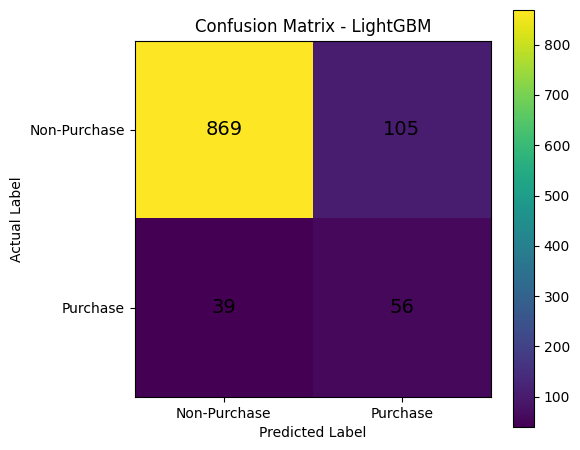

<Figure size 700x500 with 0 Axes>

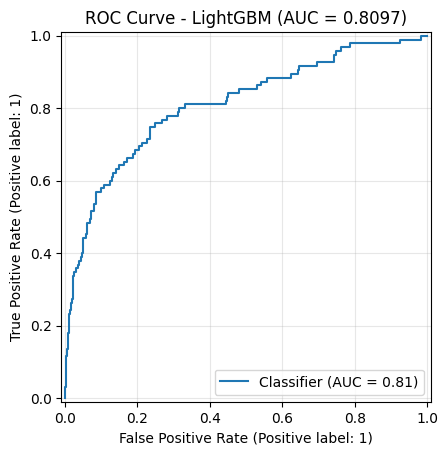

<Figure size 700x500 with 0 Axes>

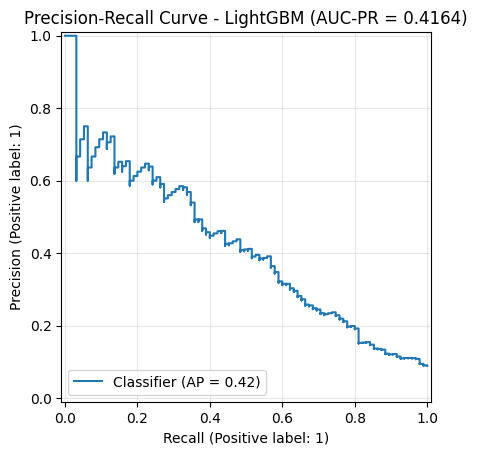

In [16]:
# ============================================================
# STEP 13 — MODEL PERFORMANCE VISUALIZATION
# ============================================================

print("=" * 60)
print("STEP 13 — MODEL PERFORMANCE VISUALIZATION")
print("=" * 60)

from sklearn.metrics import (
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# ------------------------------------------------------------
# 1. Confusion Matrix Visualization
# ------------------------------------------------------------

plt.figure(figsize=(6, 5))

plt.imshow(cm, interpolation="nearest")

plt.title("Confusion Matrix - LightGBM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["Non-Purchase", "Purchase"]
)

plt.yticks(
    [0, 1],
    ["Non-Purchase", "Purchase"]
)

# Add numbers inside the matrix
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=14
        )

plt.colorbar()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. ROC Curve
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title(
    f"ROC Curve - LightGBM (AUC = {auc_roc:.4f})"
)

plt.grid(alpha=0.3)
plt.show()


# ------------------------------------------------------------
# 3. Precision-Recall Curve
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title(
    f"Precision-Recall Curve - LightGBM "
    f"(AUC-PR = {auc_pr:.4f})"
)

plt.grid(alpha=0.3)
plt.show()



STEP 14 — FEATURE IMPORTANCE ANALYSIS

Feature importance ranking:


,Feature,Importance
0,session_duration,1264
1,average_price,896
2,min_price,886
3,max_price,869
4,unique_products,517
5,event_count,483
6,unique_brands,274
7,view_count,242
8,hour,178
9,unique_categories,155



TOP 10 IMPORTANT FEATURES


,Feature,Importance
0,session_duration,1264
1,average_price,896
2,min_price,886
3,max_price,869
4,unique_products,517
5,event_count,483
6,unique_brands,274
7,view_count,242
8,hour,178
9,unique_categories,155


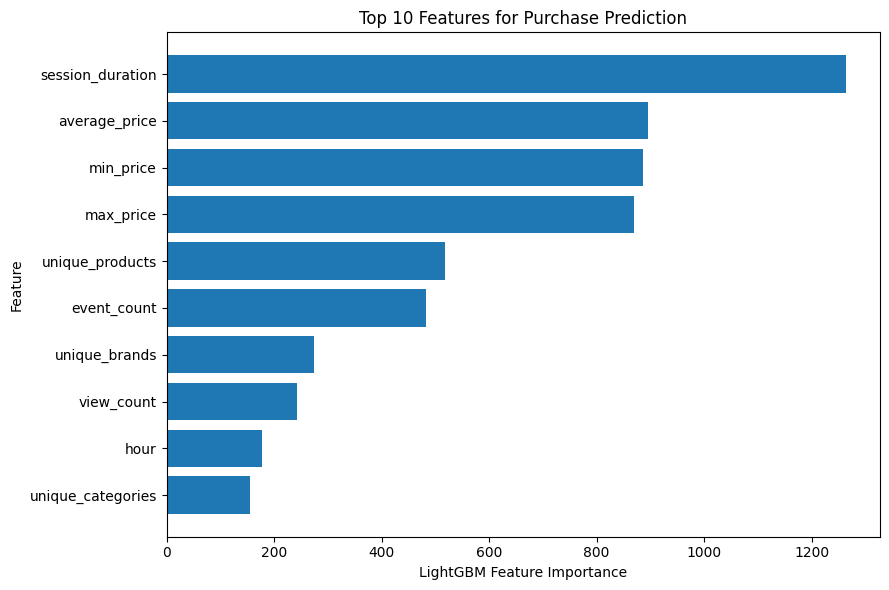


FEATURE IMPORTANCE SUMMARY
Most important feature: session_duration
Importance value: 1264


In [17]:
# ============================================================
# STEP 14 — FEATURE IMPORTANCE ANALYSIS
# ============================================================

print("=" * 60)
print("STEP 14 — FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# 1. Extract feature importance
# ------------------------------------------------------------

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgbm_model.feature_importances_
})

# Sort from highest to lowest
feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 2. Display all feature importance values
# ------------------------------------------------------------

print("\nFeature importance ranking:")
display(feature_importance)

# ------------------------------------------------------------
# 3. Display top 10 features
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TOP 10 IMPORTANT FEATURES")
print("=" * 60)

display(
    feature_importance.head(10)
)

# ------------------------------------------------------------
# 4. Plot top 10 features
# ------------------------------------------------------------

top_10 = feature_importance.head(10).sort_values(
    "Importance"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_10["Feature"],
    top_10["Importance"]
)

plt.xlabel("LightGBM Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features for Purchase Prediction")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Print interpretation
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE SUMMARY")
print("=" * 60)

print(
    f"Most important feature: "
    f"{feature_importance.iloc[0]['Feature']}"
)

print(
    f"Importance value: "
    f"{feature_importance.iloc[0]['Importance']}"
)



In [18]:
# ============================================================
# STEP 15 — IMPORT ADDITIONAL MODELS
# ============================================================

print("=" * 60)
print("STEP 15 — ADDITIONAL MODELS")
print("=" * 60)

from xgboost import XGBClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix
)

print("✓ XGBoost imported")
print("✓ Random Forest imported")
print("✓ Logistic Regression imported")

STEP 15 — ADDITIONAL MODELS
✓ XGBoost imported
✓ Random Forest imported
✓ Logistic Regression imported


In [19]:
# ============================================================
# STEP 16 — TRAIN XGBOOST
# ============================================================

print("=" * 60)
print("STEP 16 — XGBOOST PURCHASE PREDICTION")
print("=" * 60)

# ------------------------------------------------------------
# Calculate class imbalance ratio
# ------------------------------------------------------------

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("\nClass distribution:")
print("Non-Purchase:", negative_count)
print("Purchase    :", positive_count)

print(f"\nScale pos weight: {scale_pos_weight:.2f}")

# ------------------------------------------------------------
# Create XGBoost model
# ------------------------------------------------------------

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

print("\nTraining XGBoost...")

xgb_model.fit(
    X_train,
    y_train
)

print("✓ XGBoost training completed!")

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("✓ Predictions generated")

# ------------------------------------------------------------
# Sample predictions
# ------------------------------------------------------------

xgb_sample = pd.DataFrame({
    "Actual": y_test.values[:15],
    "Predicted": xgb_pred[:15],
    "Purchase_Probability": xgb_prob[:15]
})

display(xgb_sample)

STEP 16 — XGBOOST PURCHASE PREDICTION

Class distribution:
Non-Purchase: 8756
Purchase    : 856

Scale pos weight: 10.23

Training XGBoost...
✓ XGBoost training completed!
✓ Predictions generated


,Actual,Predicted,Purchase_Probability
0,0,0,0.470334
1,0,0,0.373141
2,0,0,0.065919
3,0,0,0.108230
4,0,0,0.114220
5,0,0,0.316048
6,0,0,0.120652
7,0,0,0.051536
8,0,0,0.201812
9,0,1,0.769086


In [20]:
# ============================================================
# STEP 17 — XGBOOST EVALUATION
# ============================================================

print("=" * 60)
print("STEP 17 — XGBOOST MODEL EVALUATION")
print("=" * 60)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

xgb_precision = precision_score(
    y_test,
    xgb_pred,
    zero_division=0
)

xgb_recall = recall_score(
    y_test,
    xgb_pred,
    zero_division=0
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred,
    zero_division=0
)

xgb_auc_roc = roc_auc_score(
    y_test,
    xgb_prob
)

xgb_auc_pr = average_precision_score(
    y_test,
    xgb_prob
)

xgb_logloss = log_loss(
    y_test,
    xgb_prob
)

print("\nXGBOOST PERFORMANCE")
print("-" * 40)

print(f"Accuracy       : {xgb_accuracy:.4f}")
print(f"Precision      : {xgb_precision:.4f}")
print(f"Recall         : {xgb_recall:.4f}")
print(f"F1 Score       : {xgb_f1:.4f}")
print(f"AUC-ROC        : {xgb_auc_roc:.4f}")
print(f"AUC-PR         : {xgb_auc_pr:.4f}")
print(f"Log Loss       : {xgb_logloss:.4f}")

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

xgb_cm = confusion_matrix(
    y_test,
    xgb_pred
)

print("\nConfusion Matrix:")
print(xgb_cm)

STEP 17 — XGBOOST MODEL EVALUATION

XGBOOST PERFORMANCE
----------------------------------------
Accuracy       : 0.8419
Precision      : 0.3168
Recall         : 0.6737
F1 Score       : 0.4310
AUC-ROC        : 0.8221
AUC-PR         : 0.4499
Log Loss       : 0.4011

Confusion Matrix:
[[836 138]
 [ 31  64]]


In [21]:
# ============================================================
# STEP 18 — TRAIN RANDOM FOREST
# ============================================================

print("=" * 60)
print("STEP 18 — RANDOM FOREST PURCHASE PREDICTION")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("\nModel configuration:")
print("Algorithm       : Random Forest")
print("Number of trees : 300")
print("Max depth       : 12")
print("Class weighting : Balanced")

print("\nTraining Random Forest...")

rf_model.fit(
    X_train,
    y_train
)

print("✓ Random Forest training completed!")

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("✓ Predictions generated")

# ------------------------------------------------------------
# Sample
# ------------------------------------------------------------

rf_sample = pd.DataFrame({
    "Actual": y_test.values[:15],
    "Predicted": rf_pred[:15],
    "Purchase_Probability": rf_prob[:15]
})

display(rf_sample)

STEP 18 — RANDOM FOREST PURCHASE PREDICTION

Model configuration:
Algorithm       : Random Forest
Number of trees : 300
Max depth       : 12
Class weighting : Balanced

Training Random Forest...
✓ Random Forest training completed!
✓ Predictions generated


,Actual,Predicted,Purchase_Probability
0,0,0,0.346386
1,0,0,0.260353
2,0,0,0.058037
3,0,0,0.030687
4,0,0,0.106226
5,0,0,0.290695
6,0,0,0.187246
7,0,0,0.062277
8,0,0,0.150259
9,0,1,0.564249


In [22]:
# ============================================================
# STEP 19 — RANDOM FOREST EVALUATION
# ============================================================

print("=" * 60)
print("STEP 19 — RANDOM FOREST MODEL EVALUATION")
print("=" * 60)

rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(
    y_test,
    rf_pred,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    zero_division=0
)

rf_auc_roc = roc_auc_score(
    y_test,
    rf_prob
)

rf_auc_pr = average_precision_score(
    y_test,
    rf_prob
)

rf_logloss = log_loss(
    y_test,
    rf_prob
)

print("\nRANDOM FOREST PERFORMANCE")
print("-" * 40)

print(f"Accuracy       : {rf_accuracy:.4f}")
print(f"Precision      : {rf_precision:.4f}")
print(f"Recall         : {rf_recall:.4f}")
print(f"F1 Score       : {rf_f1:.4f}")
print(f"AUC-ROC        : {rf_auc_roc:.4f}")
print(f"AUC-PR         : {rf_auc_pr:.4f}")
print(f"Log Loss       : {rf_logloss:.4f}")

rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

print("\nConfusion Matrix:")
print(rf_cm)

STEP 19 — RANDOM FOREST MODEL EVALUATION

RANDOM FOREST PERFORMANCE
----------------------------------------
Accuracy       : 0.8859
Precision      : 0.3805
Recall         : 0.4526
F1 Score       : 0.4135
AUC-ROC        : 0.8216
AUC-PR         : 0.4092
Log Loss       : 0.3426

Confusion Matrix:
[[904  70]
 [ 52  43]]


In [23]:
# ============================================================
# STEP 20 — COMPARE BASE MODELS
# ============================================================

print("=" * 60)
print("STEP 20 — BASE MODEL COMPARISON")
print("=" * 60)

comparison_df = pd.DataFrame({
    "Model": [
        "LightGBM",
        "XGBoost",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy,
        xgb_accuracy,
        rf_accuracy
    ],

    "Precision": [
        precision,
        xgb_precision,
        rf_precision
    ],

    "Recall": [
        recall,
        xgb_recall,
        rf_recall
    ],

    "F1": [
        f1,
        xgb_f1,
        rf_f1
    ],

    "AUC-ROC": [
        auc_roc,
        xgb_auc_roc,
        rf_auc_roc
    ],

    "AUC-PR": [
        auc_pr,
        xgb_auc_pr,
        rf_auc_pr
    ],

    "Log Loss": [
        logloss,
        xgb_logloss,
        rf_logloss
    ]
})

display(
    comparison_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "AUC-ROC": "{:.4f}",
        "AUC-PR": "{:.4f}",
        "Log Loss": "{:.4f}"
    })
)

STEP 20 — BASE MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,AUC-ROC,AUC-PR,Log Loss
0,LightGBM,0.8653,0.3478,0.5895,0.4375,0.8097,0.4164,0.3605
1,XGBoost,0.8419,0.3168,0.6737,0.4310,0.8221,0.4499,0.4011
2,Random Forest,0.8859,0.3805,0.4526,0.4135,0.8216,0.4092,0.3426


In [24]:
# ============================================================
# STEP 21 — PROPER STACKING WITH OUT-OF-FOLD PREDICTIONS
# ============================================================

print("=" * 60)
print("STEP 21 — PROPER STACKING ENSEMBLE")
print("=" * 60)

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

# ------------------------------------------------------------
# Define base models
# ------------------------------------------------------------

base_models = {
    "LightGBM": lgbm_model,
    "XGBoost": xgb_model,
    "RandomForest": rf_model
}

# ------------------------------------------------------------
# Create arrays for out-of-fold predictions
# ------------------------------------------------------------

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_predictions = np.zeros(
    (len(X_train), len(base_models))
)

test_predictions = np.zeros(
    (len(X_test), len(base_models))
)

# ------------------------------------------------------------
# Train each base model using 5-fold CV
# ------------------------------------------------------------

for model_index, (model_name, model) in enumerate(
    base_models.items()
):

    print(f"\nTraining {model_name}...")

    fold_test_predictions = []

    for fold, (train_idx, valid_idx) in enumerate(
        skf.split(X_train, y_train),
        start=1
    ):

        X_fold_train = X_train.iloc[train_idx]
        X_fold_valid = X_train.iloc[valid_idx]

        y_fold_train = y_train.iloc[train_idx]
        y_fold_valid = y_train.iloc[valid_idx]

        # Clone model
        fold_model = clone(model)

        # Train
        fold_model.fit(
            X_fold_train,
            y_fold_train
        )

        # Validation predictions
        oof_predictions[
            valid_idx,
            model_index
        ] = fold_model.predict_proba(
            X_fold_valid
        )[:, 1]

        # Test predictions
        fold_test_predictions.append(
            fold_model.predict_proba(
                X_test
            )[:, 1]
        )

        print(f"  Fold {fold} completed")

    # Average test predictions across folds
    test_predictions[
        :,
        model_index
    ] = np.mean(
        fold_test_predictions,
        axis=0
    )

    print(f"✓ {model_name} completed")

# ------------------------------------------------------------
# Convert to DataFrames
# ------------------------------------------------------------

oof_df = pd.DataFrame(
    oof_predictions,
    columns=[
        "LightGBM",
        "XGBoost",
        "RandomForest"
    ]
)

test_stack_df = pd.DataFrame(
    test_predictions,
    columns=[
        "LightGBM",
        "XGBoost",
        "RandomForest"
    ]
)

print("\n" + "=" * 60)
print("OUT-OF-FOLD PREDICTIONS")
print("=" * 60)

display(oof_df.head())

print("\nTest predictions:")
display(test_stack_df.head())

STEP 21 — PROPER STACKING ENSEMBLE

Training LightGBM...
  Fold 1 completed
  Fold 2 completed
  Fold 3 completed
  Fold 4 completed
  Fold 5 completed
✓ LightGBM completed

Training XGBoost...
  Fold 1 completed
  Fold 2 completed
  Fold 3 completed
  Fold 4 completed
  Fold 5 completed
✓ XGBoost completed

Training RandomForest...
  Fold 1 completed
  Fold 2 completed
  Fold 3 completed
  Fold 4 completed
  Fold 5 completed
✓ RandomForest completed

OUT-OF-FOLD PREDICTIONS


,LightGBM,XGBoost,RandomForest
0,0.200722,0.171298,0.176956
1,0.882388,0.811946,0.673032
2,0.009650,0.029525,0.035027
3,0.258290,0.297430,0.173075
4,0.072653,0.150375,0.119022



Test predictions:


,LightGBM,XGBoost,RandomForest
0,0.343482,0.455017,0.327003
1,0.162362,0.288822,0.237003
2,0.030433,0.036585,0.070931
3,0.036646,0.071437,0.036155
4,0.117615,0.130204,0.102887


In [25]:
# ============================================================
# STEP 22 — TRAIN META MODEL
# ============================================================

print("=" * 60)
print("STEP 22 — STACKING META MODEL")
print("=" * 60)

meta_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

meta_model.fit(
    oof_df,
    y_train
)

print("✓ Logistic Regression meta-model trained")

# ------------------------------------------------------------
# Generate final stacking probabilities
# ------------------------------------------------------------

stack_prob = meta_model.predict_proba(
    test_stack_df
)[:, 1]

# Default threshold
stack_pred = (
    stack_prob >= 0.50
).astype(int)

print("✓ Stacking predictions generated")

# ------------------------------------------------------------
# Sample predictions
# ------------------------------------------------------------

stack_sample = pd.DataFrame({
    "Actual": y_test.values[:15],
    "Stacking_Probability": stack_prob[:15],
    "Stacking_Prediction": stack_pred[:15]
})

display(stack_sample)

STEP 22 — STACKING META MODEL
✓ Logistic Regression meta-model trained
✓ Stacking predictions generated


,Actual,Stacking_Probability,Stacking_Prediction
0,0,0.522755,1
1,0,0.349919,0
2,0,0.164304,0
3,0,0.167490,0
4,0,0.218640,0
5,0,0.348104,0
6,0,0.237420,0
7,0,0.170864,0
8,0,0.267980,0
9,0,0.846750,1


In [26]:
# ============================================================
# STEP 23 — STACKING ENSEMBLE EVALUATION
# ============================================================

print("=" * 60)
print("STEP 23 — STACKING ENSEMBLE EVALUATION")
print("=" * 60)

stack_accuracy = accuracy_score(
    y_test,
    stack_pred
)

stack_precision = precision_score(
    y_test,
    stack_pred,
    zero_division=0
)

stack_recall = recall_score(
    y_test,
    stack_pred,
    zero_division=0
)

stack_f1 = f1_score(
    y_test,
    stack_pred,
    zero_division=0
)

stack_auc_roc = roc_auc_score(
    y_test,
    stack_prob
)

stack_auc_pr = average_precision_score(
    y_test,
    stack_prob
)

stack_logloss = log_loss(
    y_test,
    stack_prob
)

print("\nSTACKING ENSEMBLE PERFORMANCE")
print("-" * 45)

print(f"Accuracy       : {stack_accuracy:.4f}")
print(f"Precision      : {stack_precision:.4f}")
print(f"Recall         : {stack_recall:.4f}")
print(f"F1 Score       : {stack_f1:.4f}")
print(f"AUC-ROC        : {stack_auc_roc:.4f}")
print(f"AUC-PR         : {stack_auc_pr:.4f}")
print(f"Log Loss       : {stack_logloss:.4f}")

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

stack_cm = confusion_matrix(
    y_test,
    stack_pred
)

print("\nConfusion Matrix:")
print(stack_cm)

STEP 23 — STACKING ENSEMBLE EVALUATION

STACKING ENSEMBLE PERFORMANCE
---------------------------------------------
Accuracy       : 0.8148
Precision      : 0.2790
Recall         : 0.6842
F1 Score       : 0.3963
AUC-ROC        : 0.8258
AUC-PR         : 0.4299
Log Loss       : 0.4958

Confusion Matrix:
[[806 168]
 [ 30  65]]


In [27]:
# ============================================================
# STEP 24 — LIGHTGBM VS STACKING
# ============================================================

print("=" * 60)
print("STEP 24 — BASELINE VS PROPOSED MODEL")
print("=" * 60)

baseline_vs_ensemble = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC-ROC",
        "AUC-PR",
        "Log Loss"
    ],

    "LightGBM": [
        accuracy,
        precision,
        recall,
        f1,
        auc_roc,
        auc_pr,
        logloss
    ],

    "Stacking Ensemble": [
        stack_accuracy,
        stack_precision,
        stack_recall,
        stack_f1,
        stack_auc_roc,
        stack_auc_pr,
        stack_logloss
    ]
})

display(
    baseline_vs_ensemble.style.format({
        "LightGBM": "{:.4f}",
        "Stacking Ensemble": "{:.4f}"
    })
)

STEP 24 — BASELINE VS PROPOSED MODEL


,Metric,LightGBM,Stacking Ensemble
0,Accuracy,0.8653,0.8148
1,Precision,0.3478,0.2790
2,Recall,0.5895,0.6842
3,F1 Score,0.4375,0.3963
4,AUC-ROC,0.8097,0.8258
5,AUC-PR,0.4164,0.4299
6,Log Loss,0.3605,0.4958


In [28]:
# ============================================================
# STEP 25 — THRESHOLD OPTIMIZATION
# ============================================================

print("=" * 60)
print("STEP 25 — THRESHOLD OPTIMIZATION")
print("=" * 60)

threshold_results = []

thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

for threshold in thresholds:

    threshold_pred = (
        stack_prob >= threshold
    ).astype(int)

    threshold_precision = precision_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    threshold_recall = recall_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    threshold_f1 = f1_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": threshold_precision,
        "Recall": threshold_recall,
        "F1": threshold_f1
    })

threshold_df = pd.DataFrame(
    threshold_results
)

print("\nThreshold results:")

display(
    threshold_df.style.format({
        "Threshold": "{:.2f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)

STEP 25 — THRESHOLD OPTIMIZATION

Threshold results:


,Threshold,Precision,Recall,F1
0,0.10,0.0889,1.0000,0.1632
1,0.15,0.0895,1.0000,0.1642
2,0.20,0.1072,0.9579,0.1928
3,0.25,0.1349,0.9158,0.2351
4,0.30,0.1650,0.8842,0.2781
5,0.35,0.1913,0.8316,0.3110
6,0.40,0.2173,0.7684,0.3387
7,0.45,0.2438,0.7263,0.3651
8,0.50,0.2790,0.6842,0.3963
9,0.55,0.3119,0.6632,0.4242


In [29]:
# ============================================================
# STEP 26 — SELECT BEST THRESHOLD
# ============================================================

best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold = best_row["Threshold"]

best_precision = best_row["Precision"]
best_recall = best_row["Recall"]
best_f1 = best_row["F1"]

print("=" * 60)
print("BEST THRESHOLD")
print("=" * 60)

print(f"Best Threshold : {best_threshold:.2f}")
print(f"Precision      : {best_precision:.4f}")
print(f"Recall         : {best_recall:.4f}")
print(f"F1 Score       : {best_f1:.4f}")

BEST THRESHOLD
Best Threshold : 0.65
Precision      : 0.3901
Recall         : 0.5789
F1 Score       : 0.4661


In [30]:
# ============================================================
# STEP 27 — FINAL OPTIMIZED PREDICTIONS
# ============================================================

print("=" * 60)
print("STEP 27 — FINAL OPTIMIZED MODEL")
print("=" * 60)

final_pred = (
    stack_prob >= best_threshold
).astype(int)

print("\nFinal model:")
print("Stacking Ensemble + Threshold Optimization")

print(f"Decision threshold: {best_threshold:.2f}")

# ------------------------------------------------------------
# Final metrics
# ------------------------------------------------------------

final_accuracy = accuracy_score(
    y_test,
    final_pred
)

final_precision = precision_score(
    y_test,
    final_pred,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_pred,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_pred,
    zero_division=0
)

print("\nFINAL PERFORMANCE")
print("-" * 40)

print(f"Accuracy       : {final_accuracy:.4f}")
print(f"Precision      : {final_precision:.4f}")
print(f"Recall         : {final_recall:.4f}")
print(f"F1 Score       : {final_f1:.4f}")

# AUC metrics do not change with threshold
print(f"AUC-ROC        : {stack_auc_roc:.4f}")
print(f"AUC-PR         : {stack_auc_pr:.4f}")

# ------------------------------------------------------------
# Final confusion matrix
# ------------------------------------------------------------

final_cm = confusion_matrix(
    y_test,
    final_pred
)

print("\nFINAL CONFUSION MATRIX")
print(final_cm)

STEP 27 — FINAL OPTIMIZED MODEL

Final model:
Stacking Ensemble + Threshold Optimization
Decision threshold: 0.65

FINAL PERFORMANCE
----------------------------------------
Accuracy       : 0.8821
Precision      : 0.3901
Recall         : 0.5789
F1 Score       : 0.4661
AUC-ROC        : 0.8258
AUC-PR         : 0.4299

FINAL CONFUSION MATRIX
[[888  86]
 [ 40  55]]


In [31]:
# ============================================================
# STEP 28 — FINAL MODEL COMPARISON
# ============================================================

print("=" * 60)
print("STEP 28 — FINAL MODEL COMPARISON")
print("=" * 60)

final_comparison = pd.DataFrame({

    "Model": [
        "LightGBM",
        "XGBoost",
        "Random Forest",
        "Stacking Ensemble",
        "Stacking + Optimized Threshold"
    ],

    "Accuracy": [
        accuracy,
        xgb_accuracy,
        rf_accuracy,
        stack_accuracy,
        final_accuracy
    ],

    "Precision": [
        precision,
        xgb_precision,
        rf_precision,
        stack_precision,
        final_precision
    ],

    "Recall": [
        recall,
        xgb_recall,
        rf_recall,
        stack_recall,
        final_recall
    ],

    "F1": [
        f1,
        xgb_f1,
        rf_f1,
        stack_f1,
        final_f1
    ],

    "AUC-ROC": [
        auc_roc,
        xgb_auc_roc,
        rf_auc_roc,
        stack_auc_roc,
        stack_auc_roc
    ],

    "AUC-PR": [
        auc_pr,
        xgb_auc_pr,
        rf_auc_pr,
        stack_auc_pr,
        stack_auc_pr
    ]
})

display(
    final_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "AUC-ROC": "{:.4f}",
        "AUC-PR": "{:.4f}"
    })
)

STEP 28 — FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,AUC-ROC,AUC-PR
0,LightGBM,0.8653,0.3478,0.5895,0.4375,0.8097,0.4164
1,XGBoost,0.8419,0.3168,0.6737,0.4310,0.8221,0.4499
2,Random Forest,0.8859,0.3805,0.4526,0.4135,0.8216,0.4092
3,Stacking Ensemble,0.8148,0.2790,0.6842,0.3963,0.8258,0.4299
4,Stacking + Optimized Threshold,0.8821,0.3901,0.5789,0.4661,0.8258,0.4299


In [32]:
# ============================================================
# STEP 29 — CUSTOM USER INPUT TESTING
# ============================================================

print("=" * 70)
print("CUSTOM SESSION PURCHASE PREDICTION")
print("=" * 70)

# ------------------------------------------------------------
# Test cases
# ------------------------------------------------------------

test_cases = {

    "1 - Casual Browsing": {
        "event_count": 3,
        "view_count": 3,
        "cart_count": 0,
        "unique_products": 3,
        "unique_categories": 2,
        "unique_brands": 2,
        "average_price": 500,
        "max_price": 700,
        "min_price": 300,
        "session_duration": 30,
        "hour": 10,
        "day_of_week": 1,
        "is_weekend": 0,
        "last_action_1": 1,
        "last_action_2": 1,
        "last_action_3": 1,
        "last_action_4": 0,
        "last_action_5": 0
    },

    "2 - Interested User": {
        "event_count": 6,
        "view_count": 5,
        "cart_count": 1,
        "unique_products": 3,
        "unique_categories": 2,
        "unique_brands": 2,
        "average_price": 1000,
        "max_price": 1500,
        "min_price": 500,
        "session_duration": 180,
        "hour": 18,
        "day_of_week": 2,
        "is_weekend": 0,
        "last_action_1": 1,
        "last_action_2": 1,
        "last_action_3": 1,
        "last_action_4": 1,
        "last_action_5": 2
    },

    "3 - Strong Purchase Intent": {
        "event_count": 12,
        "view_count": 6,
        "cart_count": 6,
        "unique_products": 4,
        "unique_categories": 2,
        "unique_brands": 2,
        "average_price": 1500,
        "max_price": 2500,
        "min_price": 700,
        "session_duration": 600,
        "hour": 20,
        "day_of_week": 5,
        "is_weekend": 1,
        "last_action_1": 1,
        "last_action_2": 1,
        "last_action_3": 2,
        "last_action_4": 2,
        "last_action_5": 2
    },

    "4 - Many Views No Cart": {
        "event_count": 20,
        "view_count": 20,
        "cart_count": 0,
        "unique_products": 15,
        "unique_categories": 8,
        "unique_brands": 10,
        "average_price": 1200,
        "max_price": 5000,
        "min_price": 100,
        "session_duration": 1000,
        "hour": 19,
        "day_of_week": 4,
        "is_weekend": 0,
        "last_action_1": 1,
        "last_action_2": 1,
        "last_action_3": 1,
        "last_action_4": 1,
        "last_action_5": 1
    },

    "5 - Cart Heavy User": {
        "event_count": 18,
        "view_count": 6,
        "cart_count": 12,
        "unique_products": 6,
        "unique_categories": 3,
        "unique_brands": 4,
        "average_price": 2200,
        "max_price": 5000,
        "min_price": 800,
        "session_duration": 900,
        "hour": 21,
        "day_of_week": 6,
        "is_weekend": 1,
        "last_action_1": 1,
        "last_action_2": 2,
        "last_action_3": 2,
        "last_action_4": 2,
        "last_action_5": 2
    }
}


# ------------------------------------------------------------
# Feature order
# ------------------------------------------------------------

custom_features = [
    "event_count",
    "view_count",
    "cart_count",
    "unique_products",
    "unique_categories",
    "unique_brands",
    "average_price",
    "max_price",
    "min_price",
    "session_duration",
    "hour",
    "day_of_week",
    "is_weekend",
    "last_action_1",
    "last_action_2",
    "last_action_3",
    "last_action_4",
    "last_action_5"
]


# ------------------------------------------------------------
# Predict each test case
# ------------------------------------------------------------

results = []

for case_name, values in test_cases.items():

    # Create one-row DataFrame
    input_df = pd.DataFrame([values])

    # Make sure feature order is exactly the same
    input_df = input_df[custom_features]

    # --------------------------------------------------------
    # Base model predictions
    # --------------------------------------------------------

    lgbm_probability = lgbm_model.predict_proba(
        input_df
    )[:, 1][0]

    xgb_probability = xgb_model.predict_proba(
        input_df
    )[:, 1][0]

    rf_probability = rf_model.predict_proba(
        input_df
    )[:, 1][0]

    # --------------------------------------------------------
    # Create stacking input
    # --------------------------------------------------------

    stack_input = pd.DataFrame({
        "LightGBM": [lgbm_probability],
        "XGBoost": [xgb_probability],
        "RandomForest": [rf_probability]
    })

    # --------------------------------------------------------
    # Final stacking probability
    # --------------------------------------------------------

    purchase_probability = meta_model.predict_proba(
        stack_input
    )[:, 1][0]

    # --------------------------------------------------------
    # Final prediction
    # --------------------------------------------------------

    prediction = int(
        purchase_probability >= best_threshold
    )

    if prediction == 1:
        prediction_label = "PURCHASE"
    else:
        prediction_label = "NON-PURCHASE"

    # --------------------------------------------------------
    # Store result
    # --------------------------------------------------------

    results.append({
        "Test Case": case_name,
        "LightGBM Probability": lgbm_probability,
        "XGBoost Probability": xgb_probability,
        "Random Forest Probability": rf_probability,
        "Final Purchase Probability": purchase_probability,
        "Prediction": prediction_label
    })


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("PREDICTION RESULTS")
print("=" * 70)

display(
    results_df.style.format({
        "LightGBM Probability": "{:.2%}",
        "XGBoost Probability": "{:.2%}",
        "Random Forest Probability": "{:.2%}",
        "Final Purchase Probability": "{:.2%}"
    })
)

CUSTOM SESSION PURCHASE PREDICTION

PREDICTION RESULTS


,Test Case,LightGBM Probability,XGBoost Probability,Random Forest Probability,Final Purchase Probability,Prediction
0,1 - Casual Browsing,2.67%,3.55%,5.66%,16.00%,NON-PURCHASE
1,2 - Interested User,73.95%,66.14%,46.44%,76.31%,PURCHASE
2,3 - Strong Purchase Intent,89.94%,76.17%,61.78%,86.11%,PURCHASE
3,4 - Many Views No Cart,0.68%,2.91%,11.69%,17.07%,NON-PURCHASE
4,5 - Cart Heavy User,89.38%,73.32%,55.23%,83.66%,PURCHASE
